In [631]:
EMA_path = "./../inference/combined/EMA_manually_cleaned.json"
JAPAN_path = "./../inference/combined/JAPAN_manually_cleaned.json"
SWISSMEDIC_path = "./../inference/combined/SWISSMEDIC_manually_cleaned.json"
# AUSTRALIA_path = "./../inference/combined/AUSTRALIA_manually_cleaned.json"

SAVE_DIR = "./../inference/combined/figures/"
import os
os.makedirs(SAVE_DIR, exist_ok=True)

In [632]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import numpy as np
from matplotlib.ticker import FixedLocator, ScalarFormatter

In [ ]:
def load_data(file_path):
    """Load data from a JSON file."""
    with open(file_path, 'r') as file:
        data = json.load(file)
    return pd.DataFrame(data)

def to_lower(df):
    return df.map(lambda x: x.lower().strip() if isinstance(x, str) else x)

def remove_invalid_rows(df):
    invalid_rows = df.apply(lambda x: x.astype(str).str.contains("the response is not valid json", case=False, na=False))
    print(f"Total rows with invalid responses: {invalid_rows.any(axis=1).sum()}")
    df = df[~invalid_rows.any(axis=1)]
    return df

def prepare_for_analysis(filepath):
    df = load_data(filepath)
    df = df.transpose()
    df.replace(["not reported", "Not reported", ""], np.nan, inplace=True)
    df = remove_invalid_rows(df)
    df = to_lower(df)
    return df

def date_to_int(df, col_name):
    df = df.copy()
    original_len = len(df)
    df[col_name] = pd.to_datetime(df[col_name], errors='coerce')
    df[col_name] = df[col_name].dt.year
    df = df.dropna(subset=[col_name]).astype({col_name: 'int'})
    final_len = len(df)
    print(f"Original length: {original_len}, Final length after cleaning: {final_len}, Percentage kept: {final_len/original_len*100:.2f}%")
    return df

def plot_timeline(df, col_name, dataset_name=None):
    df = date_to_int(df, col_name)  # Ensure column is integer (e.g., year)
    unique_vals = sorted(df[col_name].unique())
    bins = np.append(unique_vals, unique_vals[-1] + 1)
    plt.figure(figsize=(8, 4))
    ax = plt.gca()
    counts, edges, patches = plt.hist(df[col_name], bins=bins, color="seagreen", edgecolor='black', align='left', alpha=0.7)
    ax.set_xticks(unique_vals)
    ax.set_xticklabels([str(int(x)) for x in unique_vals], rotation=45, ha='center')
    plt.xlabel(col_name)
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7, color='silver')
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}{dataset_name}_{col_name}_timeline.png", dpi=300, bbox_inches='tight')
    plt.show()

def plot_drug_class_distribution(df, drug_class_colormap=None, dataset_name=None):
    class_order = df['Drug_class'].value_counts().index
    palette = {cls: drug_class_colormap[cls] for cls in class_order}
    plt.figure(figsize=(8, 5))
    ax = sns.countplot(data=df, x='Drug_class', order=df['Drug_class'].value_counts().index, palette=palette, edgecolor='black')
    # Add count labels on top of bars
    for p in ax.patches:
        height = p.get_height()
        ax.text(
            x=p.get_x() + p.get_width() / 2,
            y=height + 0.5,
            s=int(height),
            ha='center', va='bottom', fontsize=9
        )
    plt.xticks(rotation=45, ha='right')
    # plt.title('Distribution of Drug Classes')
    plt.xlabel('Drug Class')
    plt.ylabel('Count')
    plt.grid(axis='y', linestyle='--', alpha=0.7, color='silver')
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}{dataset_name}_drug_class_distribution.png", dpi=300, bbox_inches='tight')
    plt.show()

def plot_drug_class_distribution_pie(df, drug_class_colormap=None, dataset_name=None):
    class_counts = df['Drug_class'].value_counts()
    cmap = plt.get_cmap('tab20')
    labels = class_counts.index
    sizes = class_counts.values
    colors = [drug_class_colormap[label] for label in labels]
    total = sizes.sum()

    plt.figure(figsize=(5, 5))
    wedges, _ = plt.pie(
        sizes,
        startangle=140,
        colors=colors,
        wedgeprops=dict(width=0.3, edgecolor='w'),
    )
    legend_labels = [f"{label} ({size / total * 100:.1f}%)" for label, size in zip(labels, sizes)]

    plt.legend(
        wedges,
        legend_labels,
        title='Drug Class',
        loc='center left',
        bbox_to_anchor=(1, 0.7),
        fontsize=9
    )
    # plt.title('Distribution of Drug Classes')
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}{dataset_name}_drug_class_distribution_pie.png", dpi=300, bbox_inches='tight')
    plt.show()

def plot_drug_class_per_year(df, col_name, drug_class_colormap=None, dataset_name=None):
    df = date_to_int(df, col_name)
    class_counts = df.groupby([col_name, 'Drug_class']).size().unstack(fill_value=0)
    class_counts = class_counts[class_counts.sum().sort_values(ascending=False).index]
    colors = [drug_class_colormap[cls] for cls in class_counts.columns]

    fig, ax = plt.subplots(figsize=(10, 6))
    class_counts.plot(kind='bar', stacked=True, ax=ax, color=colors, edgecolor='black', width=1.0)

    ax.set_xlabel(col_name)
    ax.set_ylabel('Number of Drugs')
    # ax.set_title('Drug Class Distribution Over Years')
    ax.legend(title='Drug Class', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7, color='silver')
    plt.tight_layout()

    if dataset_name:
        plt.savefig(f"{SAVE_DIR}{dataset_name}_drug_class_per_year.png", dpi=300, bbox_inches='tight')
    plt.show()

def plot_drug_class_by_administration_route(df, drug_class_colormap=None, dataset_name=None):
    class_counts = df.groupby(['Drug_class', 'Administration_route']).size().unstack(fill_value=0)
    class_counts = class_counts[class_counts.sum().sort_values(ascending=False).index]
    colors = [drug_class_colormap[cls] for cls in class_counts.index]
    class_counts.plot(kind='bar', stacked=True, color=colors, edgecolor='black', figsize=(10, 6))
    plt.xlabel('Drug Class')
    plt.ylabel('Number of Drugs')
    # plt.title('Drug Class by Administration Route')
    plt.legend(title='Administration Route', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7, color='silver')
    plt.tight_layout()
    if dataset_name:
        plt.savefig(f"{SAVE_DIR}{dataset_name}_drug_class_by_administration_route.png", dpi=300, bbox_inches='tight')
    plt.show()

def plot_review_duration_by_agency(agency_dfs: dict, submission_col='Application_date', decision_col='Decision_date', dataset_name=None):
   
    combined_list = []

    # calculate review duration for each agency
    for agency, df in agency_dfs.items(): 
        df = df.copy()
        df[submission_col] = pd.to_datetime(df[submission_col], errors='coerce', dayfirst=True)
        df[decision_col] = pd.to_datetime(df[decision_col], errors='coerce', dayfirst=True)
        df['Review_duration_days'] = (df[decision_col] - df[submission_col]).dt.days
        valid = df.dropna(subset=['Review_duration_days'])
        valid['Agency'] = agency
        combined_list.append(valid[['Review_duration_days', 'Agency']])

    combined_df = pd.concat(combined_list, ignore_index=True)

    # add oerall data
    overall_df = combined_df.copy()
    overall_df['Agency'] = 'Overall'
    combined_df = pd.concat([combined_df, overall_df], ignore_index=True)

    # Plot
    plt.figure(figsize=(10, 6))
    ax = sns.boxplot(data=combined_df, x='Agency', y='Review_duration_days', palette='pastel')
    ax.set_ylabel('Review Duration (days, log scale)')
    ax.set_xlabel('Agency')
    ax.set_yscale("symlog", linthresh=500)
    ax.yaxis.set_major_formatter(ScalarFormatter())
    ax.yaxis.set_minor_formatter(ScalarFormatter())
    ax.ticklabel_format(style='plain', axis='y')
    ax.set_yticks([100, 200, 300, 400, 500, 700, 1000, 1500, 2000])
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

    if dataset_name:
        plt.savefig(f"{SAVE_DIR}{dataset_name}_review_duration_boxplot_by_agency_log.png", dpi=300, bbox_inches='tight')
    plt.show()

def plot_review_duration_by_disease_class(df, agency_name, submission_col='Application_date', decision_col='Decision_date', dataset_name=None):
   
    df = df.copy()
    df[submission_col] = pd.to_datetime(df[submission_col], errors='coerce', dayfirst=True)
    df[decision_col] = pd.to_datetime(df[decision_col], errors='coerce', dayfirst=True)
    df['Review_duration_days'] = (df[decision_col] - df[submission_col]).dt.days

    # Filter out invalid durations and disease classes
    df = df.dropna(subset=['Review_duration_days', 'Disease_class(es)'])
    df = df[df['Review_duration_days'] > 0]

    # Split disease classes and clean whitespace
    df['Disease_class(es)'] = df['Disease_class(es)'].str.split(';')
    df = df.explode('Disease_class(es)')
    df['Disease_class(es)'] = df['Disease_class(es)'].str.strip()  # clean whitespace

    # Plot
    plt.figure(figsize=(12, 6))
    ax = sns.boxplot(data=df, x='Disease_class(es)', y='Review_duration_days', palette='pastel')
    ax.set_ylabel('Review Duration (days)')
    ax.set_xlabel('Disease Class')
    ax.set_yscale("symlog", linthresh=500)
    ax.yaxis.set_major_formatter(ScalarFormatter())
    ax.yaxis.set_minor_formatter(ScalarFormatter())
    ax.ticklabel_format(style='plain', axis='y')
    ax.set_yticks([200, 400, 600, 800, 1000, 1500])
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

    # Save the plot
    if dataset_name:
        filename = f"{dataset_name}_review_duration_by_disease_class.png"
        plt.savefig(os.path.join(SAVE_DIR, filename), dpi=300, bbox_inches='tight')

    plt.show()
    plt.show()

In [634]:
EMA = prepare_for_analysis(EMA_path)
JAPAN = prepare_for_analysis(JAPAN_path)
SWISSMEDIC = prepare_for_analysis(SWISSMEDIC_path)

Total rows with invalid responses: 6
Total rows with invalid responses: 0
Total rows with invalid responses: 0


/var/folders/0j/2hyszkt95x38yj11dwpbgx900000gn/T/ipykernel_5367/1537664109.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace(["not reported", "Not reported", ""], np.nan, inplace=True)


In [635]:
all_classes = pd.concat([EMA['Drug_class'], JAPAN['Drug_class'], SWISSMEDIC['Drug_class']]).unique()
print("All unique drug classes across datasets:", all_classes)
cmap = plt.get_cmap('tab20')
colors = cmap(np.linspace(0, 1, len(all_classes)))
drug_class_colormap = dict(zip(all_classes, colors))

All unique drug classes across datasets: ['small molecule' 'biologics' 'peptides and proteins' 'other' 'vaccine'
 'cell and gene therapy' 'vitamins' 'antibiotic' 'antibiotics'
 'antibody-drug conjugate']


In [636]:
EMA.columns

Index(['Marketing_authorisation_number', 'Procedure_number', 'Drug_name',
       'Non_proprietary_name', 'Marketing_authorisation_holder', 'Drug_class',
       'Pharmaceutical_form', 'Administration_route', 'Decision',
       'Current_status', 'Decision_date', 'Decision_year',
       'Orphan_drug_status', 'Indication_extended', 'Indication_requested',
       'Indication_approved', 'Disease_class(es)', 'Application_date',
       'Application_year', 'Nonclinical_abridged', 'Referral_body',
       'Document_name'],
      dtype='object')

Original length: 1987, Final length after cleaning: 1687, Percentage kept: 84.90%


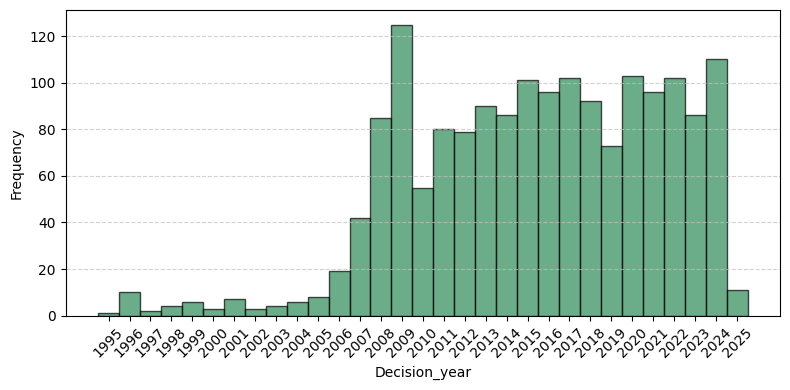

Original length: 408, Final length after cleaning: 408, Percentage kept: 100.00%


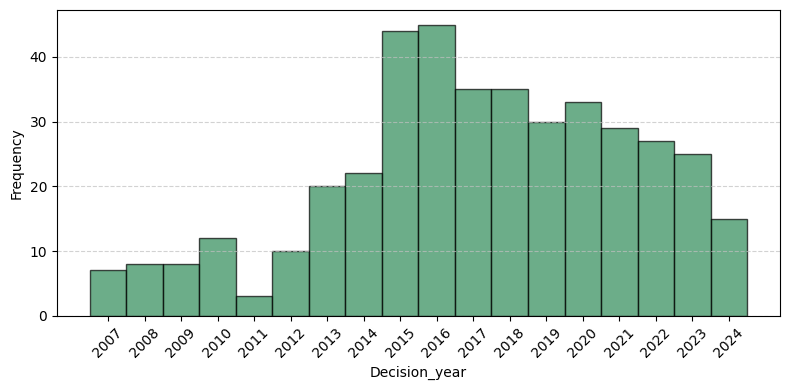

Original length: 234, Final length after cleaning: 234, Percentage kept: 100.00%


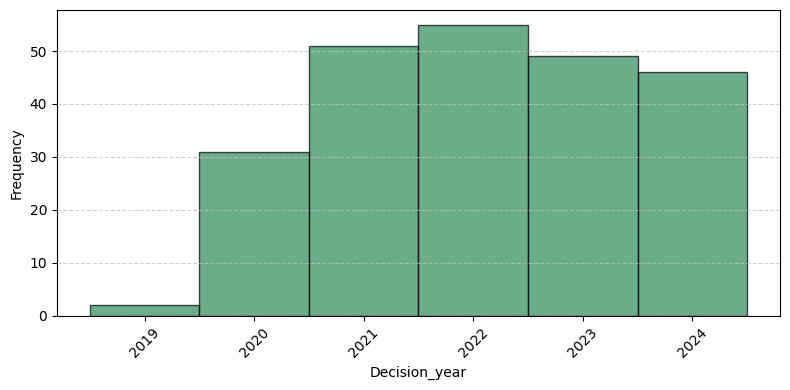

In [637]:
plot_timeline(EMA, col_name='Decision_year', dataset_name='EMA')
plot_timeline(JAPAN, col_name='Decision_year', dataset_name='JAPAN')
plot_timeline(SWISSMEDIC, col_name='Decision_year', dataset_name='SWISSMEDIC')

In [638]:
print(EMA["Application_year"].unique())

[nan '2023' '2021' '2022' '2010' '2014' '2017' '2008' '2011' '2007' '2009'
 '2013' '2019' '2018' '2020' '2015' '2012' '2016' '2006' '2005' '2024'
 '2004' '1999' '1995' '2003' '2001' '2000' '1998']


Original length: 1987, Final length after cleaning: 1491, Percentage kept: 75.04%


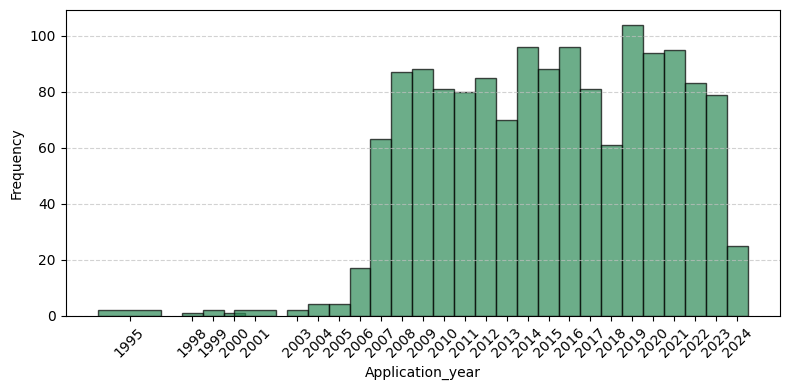

Original length: 408, Final length after cleaning: 408, Percentage kept: 100.00%


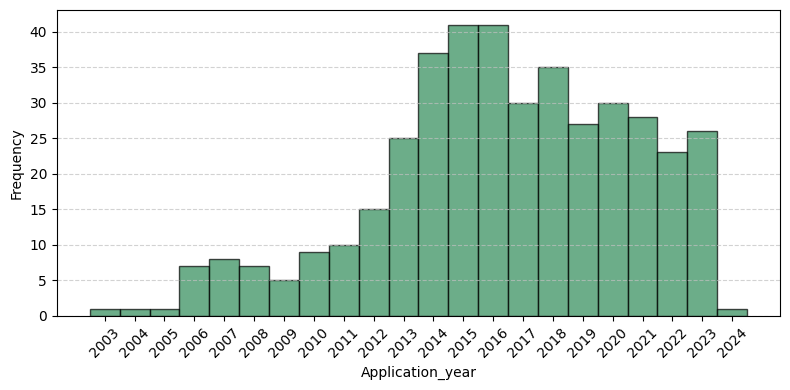

Original length: 234, Final length after cleaning: 234, Percentage kept: 100.00%


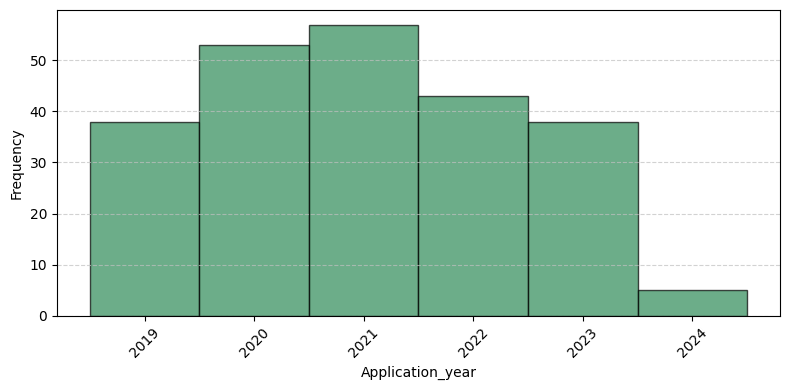

In [639]:
plot_timeline(EMA, col_name='Application_year', dataset_name='EMA')
plot_timeline(JAPAN, col_name='Application_year', dataset_name='JAPAN')
plot_timeline(SWISSMEDIC, col_name='Application_year', dataset_name='SWISSMEDIC')

In [640]:
print(EMA["Application_year"].unique())

[nan '2023' '2021' '2022' '2010' '2014' '2017' '2008' '2011' '2007' '2009'
 '2013' '2019' '2018' '2020' '2015' '2012' '2016' '2006' '2005' '2024'
 '2004' '1999' '1995' '2003' '2001' '2000' '1998']


In [641]:
EMA["Drug_class"].unique()

array(['small molecule', 'biologics', 'peptides and proteins', 'other',
       'vaccine', 'cell and gene therapy', 'vitamins', 'antibiotic',
       'antibiotics', 'antibody-drug conjugate'], dtype=object)

/var/folders/0j/2hyszkt95x38yj11dwpbgx900000gn/T/ipykernel_5367/1537664109.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Drug_class', order=df['Drug_class'].value_counts().index, palette=palette, edgecolor='black')


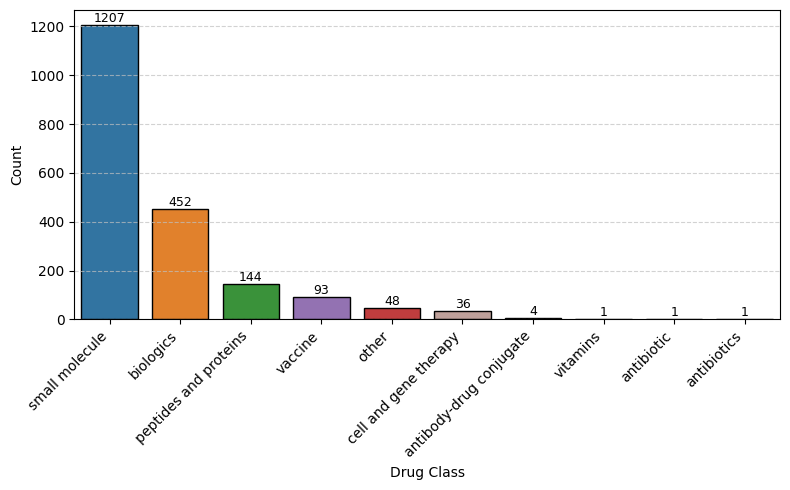

/var/folders/0j/2hyszkt95x38yj11dwpbgx900000gn/T/ipykernel_5367/1537664109.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Drug_class', order=df['Drug_class'].value_counts().index, palette=palette, edgecolor='black')


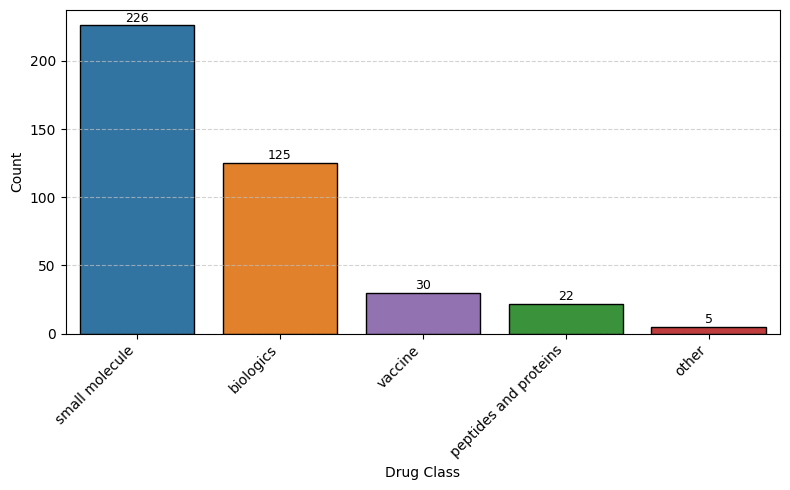

/var/folders/0j/2hyszkt95x38yj11dwpbgx900000gn/T/ipykernel_5367/1537664109.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Drug_class', order=df['Drug_class'].value_counts().index, palette=palette, edgecolor='black')


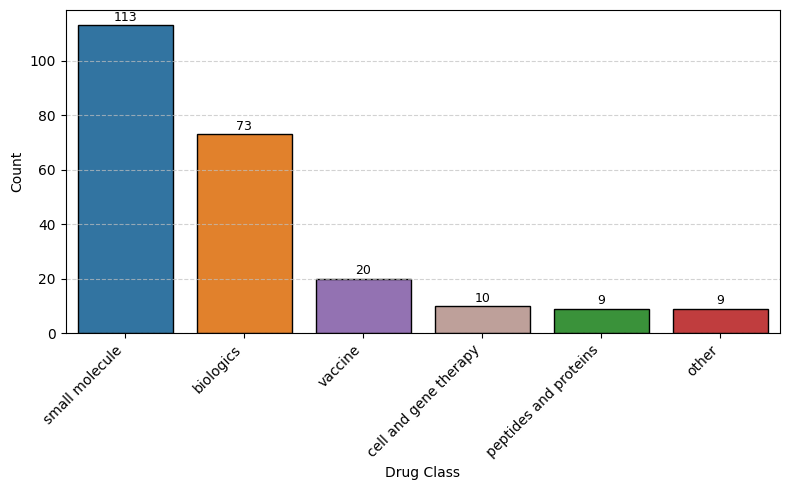

In [642]:
plot_drug_class_distribution(EMA, drug_class_colormap, dataset_name='EMA')
plot_drug_class_distribution(JAPAN, drug_class_colormap, dataset_name='JAPAN')
plot_drug_class_distribution(SWISSMEDIC, drug_class_colormap, dataset_name='SWISSMEDIC')

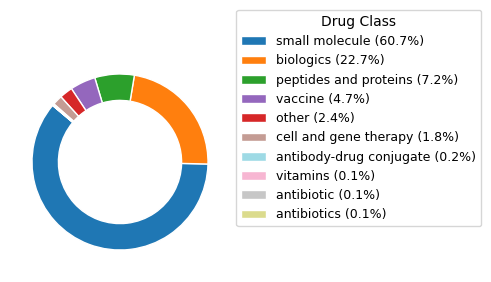

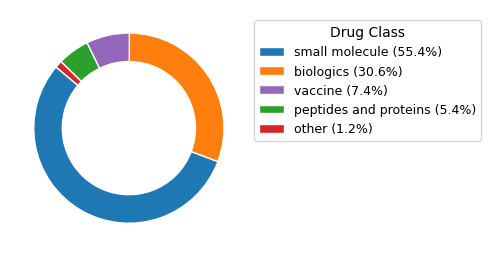

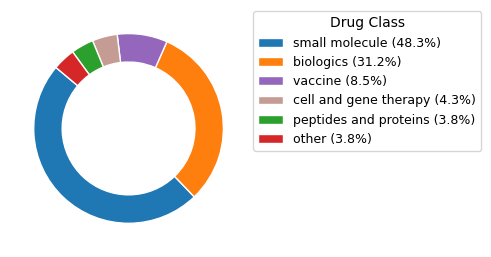

In [643]:
plot_drug_class_distribution_pie(EMA, drug_class_colormap, dataset_name='EMA')
plot_drug_class_distribution_pie(JAPAN, drug_class_colormap, dataset_name='JAPAN')
plot_drug_class_distribution_pie(SWISSMEDIC, drug_class_colormap, dataset_name='SWISSMEDIC')

Original length: 1987, Final length after cleaning: 1491, Percentage kept: 75.04%


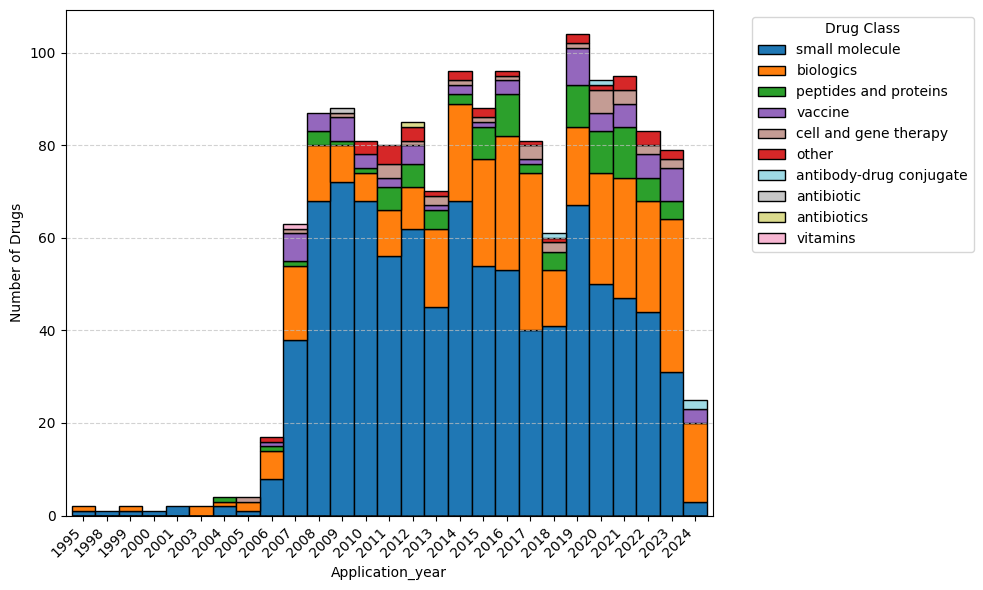

Original length: 408, Final length after cleaning: 408, Percentage kept: 100.00%


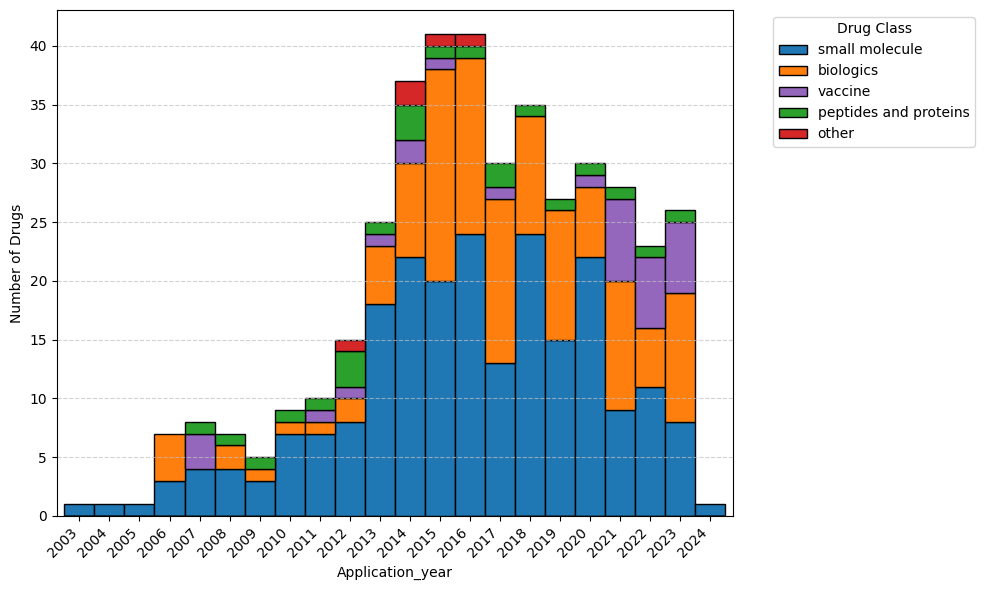

Original length: 234, Final length after cleaning: 234, Percentage kept: 100.00%


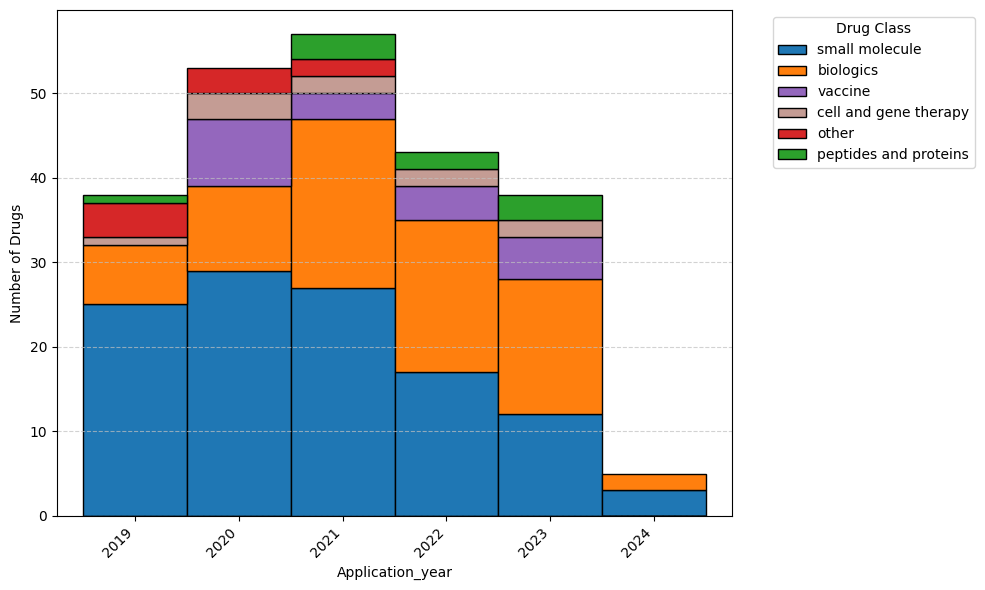

In [644]:
plot_drug_class_per_year(EMA, "Application_year", drug_class_colormap, "EMA")
plot_drug_class_per_year(JAPAN, "Application_year", drug_class_colormap, "JAPAN")
plot_drug_class_per_year(SWISSMEDIC, "Application_year", drug_class_colormap, "SWISSMEDIC")

/var/folders/0j/2hyszkt95x38yj11dwpbgx900000gn/T/ipykernel_5367/1537664109.py:135: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


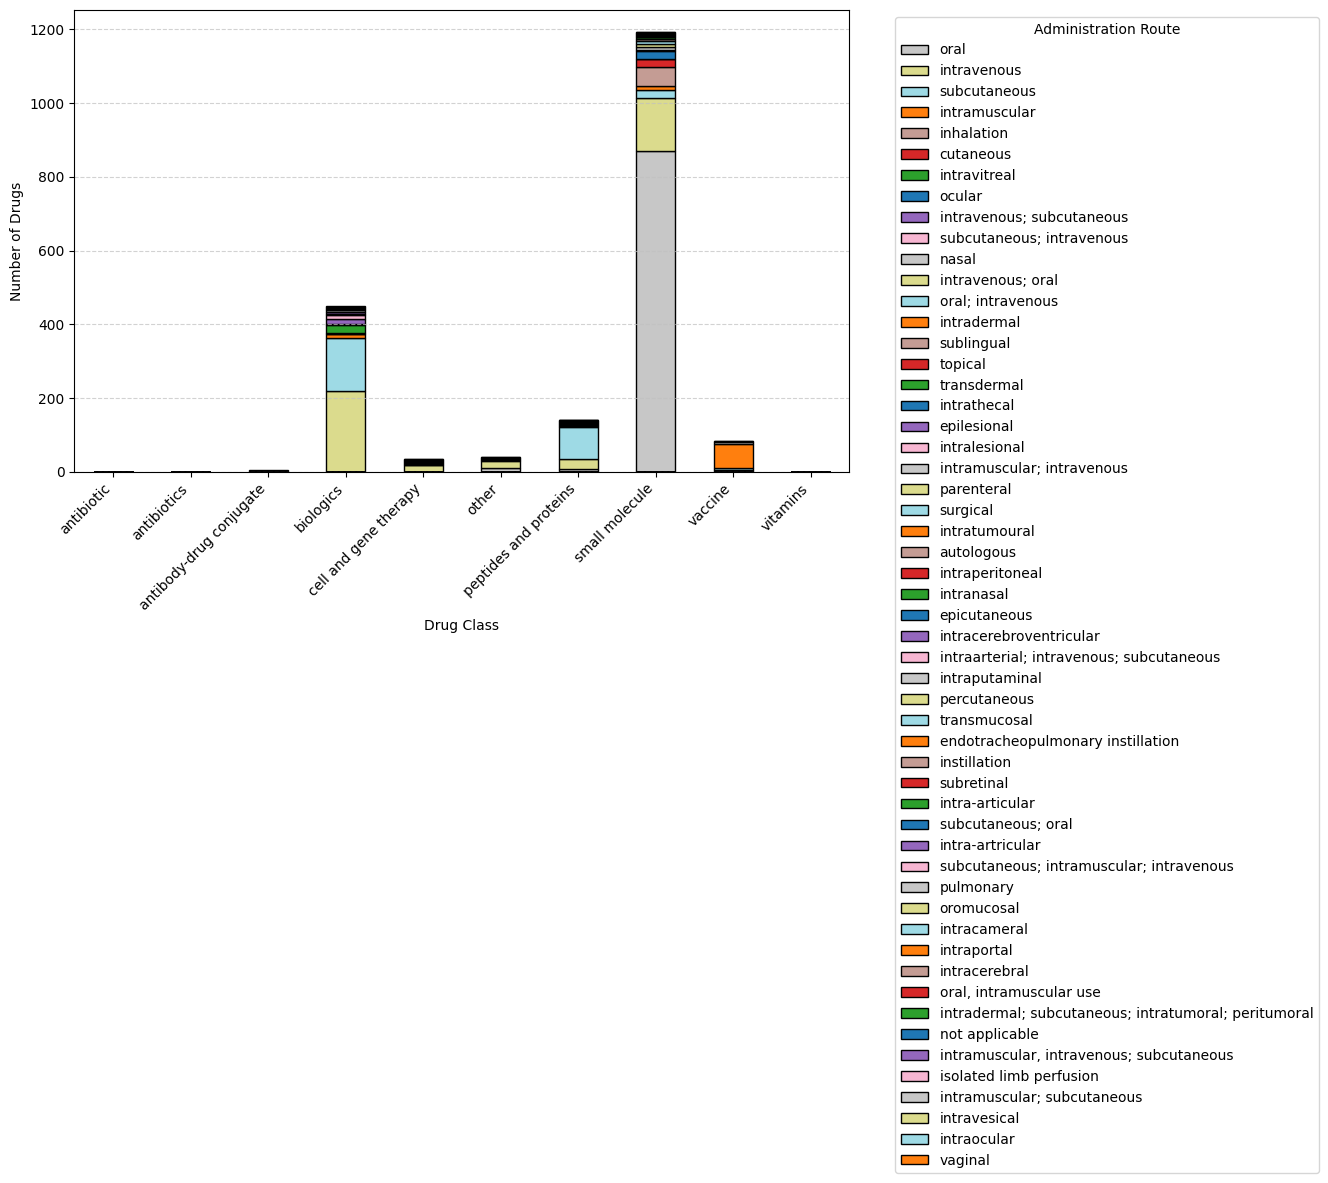

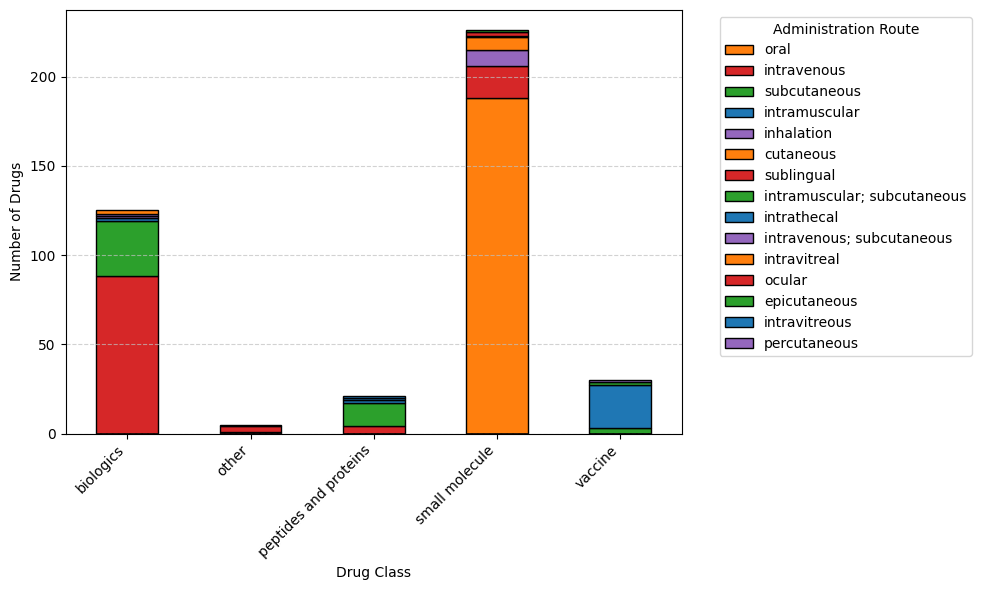

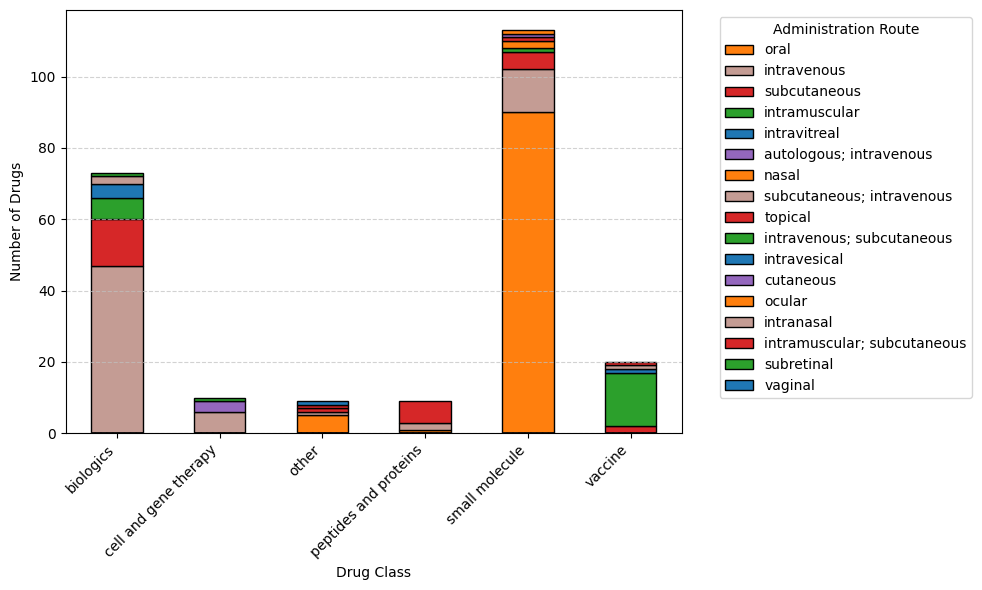

In [645]:
plot_drug_class_by_administration_route(EMA, drug_class_colormap, dataset_name="EMA")
plot_drug_class_by_administration_route(JAPAN, drug_class_colormap, dataset_name="JAPAN")
plot_drug_class_by_administration_route(SWISSMEDIC, drug_class_colormap, dataset_name="SWISSMEDIC")

In [646]:
all_holders_combined = pd.concat(
    [EMA['Marketing_authorisation_holder'], 
     JAPAN['Marketing_authorisation_holder'], 
     SWISSMEDIC['Marketing_authorisation_holder']
     ])    
all_holders_combined = all_holders_combined.dropna().unique()

def sort_by_name(df, col_name):
    df = df.copy()
    df[col_name] = df[col_name].str.lower().str.strip()
    return df.sort_values(by=col_name)

EMA_sorted = sort_by_name(EMA, 'Marketing_authorisation_holder')
JAPAN_sorted = sort_by_name(JAPAN, 'Marketing_authorisation_holder')
SWISSMEDIC_sorted = sort_by_name(SWISSMEDIC, 'Marketing_authorisation_holder')

EMA_sorted_unique = EMA_sorted['Marketing_authorisation_holder'].unique()
JAPAN_sorted_unique = JAPAN_sorted['Marketing_authorisation_holder'].unique()
SWISSMEDIC_sorted_unique = SWISSMEDIC_sorted['Marketing_authorisation_holder'].unique()

with open(f"{SAVE_DIR}/EMA_marketing_authorisation_holders.txt", 'w', encoding="utf-8") as f:
    for holder in EMA_sorted_unique:
        f.write(f"{holder}\n")
with open(f"{SAVE_DIR}/JAPAN_marketing_authorisation_holders.txt", 'w') as f:
    for holder in JAPAN_sorted_unique:
        f.write(f"{holder}\n")
with open(f"{SAVE_DIR}/SWISSMEDIC_marketing_authorisation_holders.txt", 'w') as f:
    for holder in SWISSMEDIC_sorted_unique:
        f.write(f"{holder}\n")


/var/folders/0j/2hyszkt95x38yj11dwpbgx900000gn/T/ipykernel_5367/1537664109.py:151: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Agency'] = agency
/var/folders/0j/2hyszkt95x38yj11dwpbgx900000gn/T/ipykernel_5367/1537664109.py:151: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Agency'] = agency
/var/folders/0j/2hyszkt95x38yj11dwpbgx900000gn/T/ipykernel_5367/1537664109.py:163: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` v

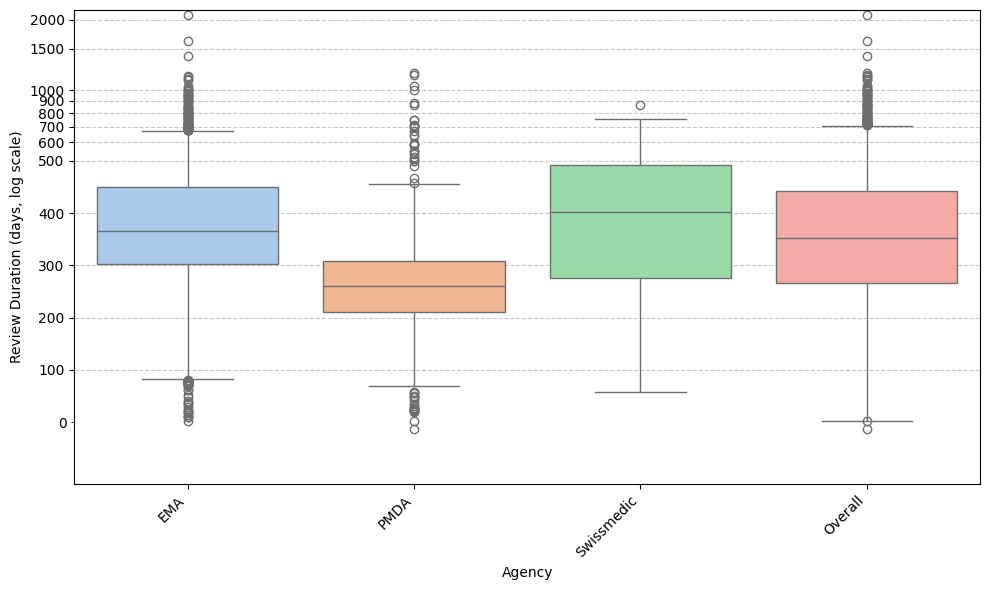

In [647]:
plot_review_duration_by_agency(
    {
        'EMA': EMA,
        'PMDA': JAPAN,
        'Swissmedic': SWISSMEDIC
    },
    submission_col='Application_date',
    decision_col='Decision_date',
    dataset_name='combined'
)

/var/folders/0j/2hyszkt95x38yj11dwpbgx900000gn/T/ipykernel_5367/1537664109.py:197: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, x='Disease_class(es)', y='Review_duration_days', palette='pastel')


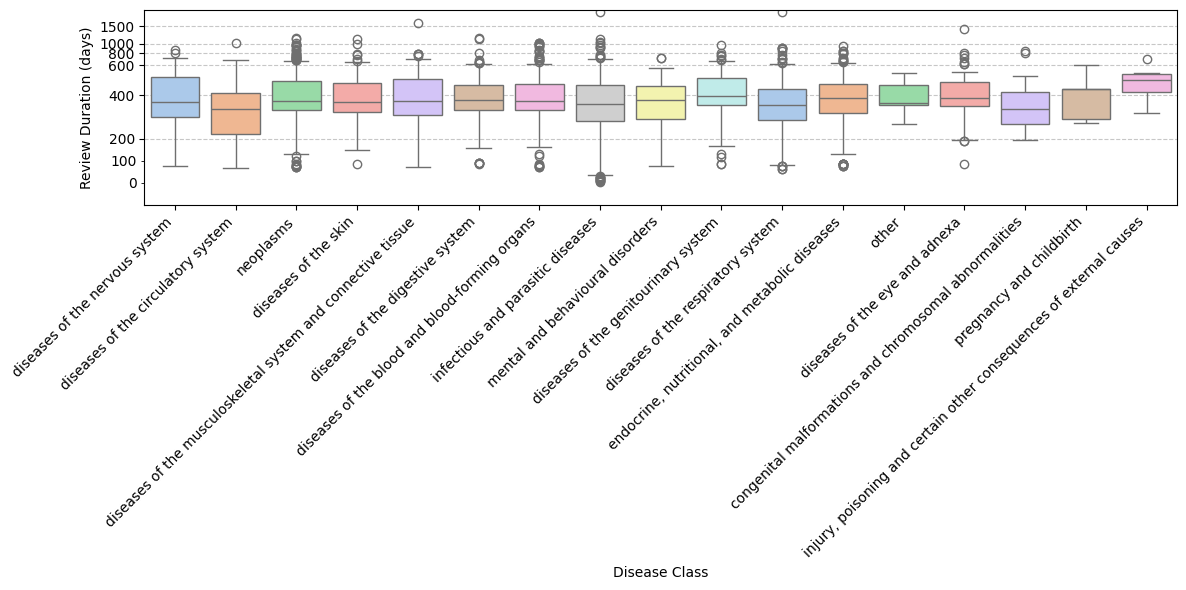

/var/folders/0j/2hyszkt95x38yj11dwpbgx900000gn/T/ipykernel_5367/1537664109.py:197: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, x='Disease_class(es)', y='Review_duration_days', palette='pastel')


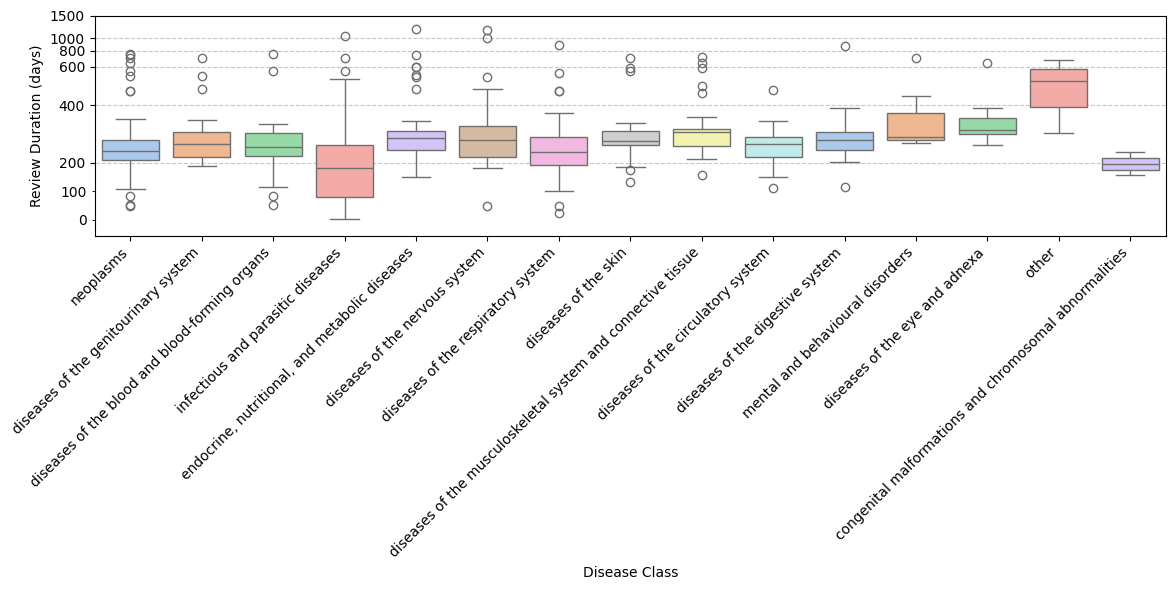

/var/folders/0j/2hyszkt95x38yj11dwpbgx900000gn/T/ipykernel_5367/1537664109.py:197: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, x='Disease_class(es)', y='Review_duration_days', palette='pastel')


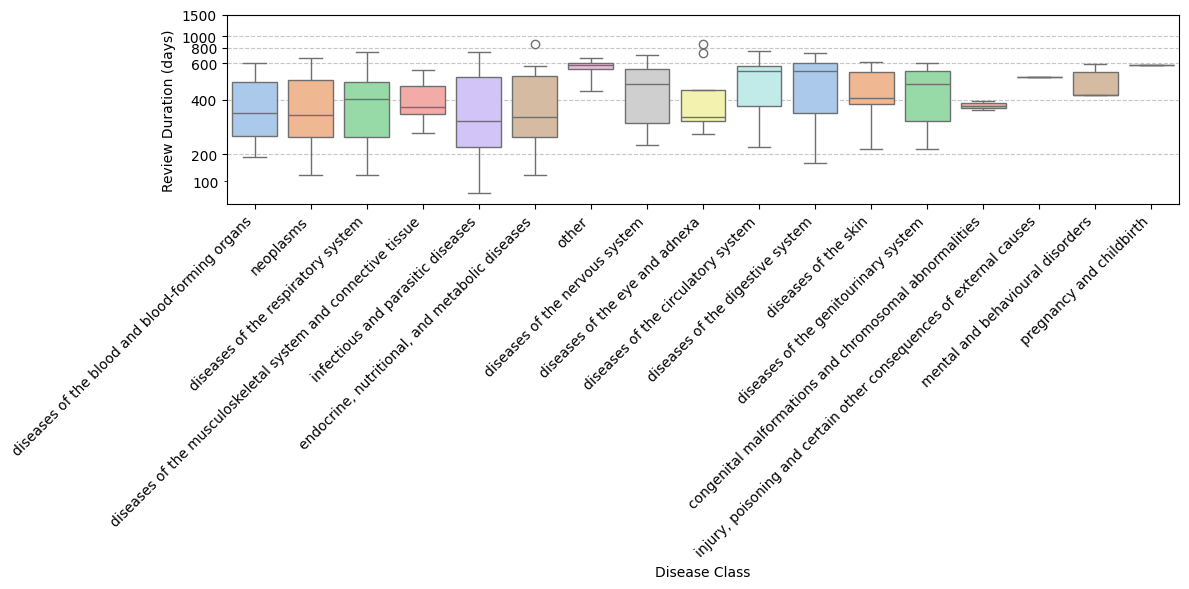

In [648]:
plot_review_duration_by_disease_class(EMA, agency_name='EMA', dataset_name='EMA')
plot_review_duration_by_disease_class(JAPAN, agency_name='PMDA', dataset_name='PMDA')
plot_review_duration_by_disease_class(SWISSMEDIC, agency_name='Swissmedic', dataset_name='Swissmedic')